<a href="https://colab.research.google.com/github/neelsoumya/visualization_lecture/blob/main/colour_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colour theory in data visualization (Python)

## Color Theory for Data Visualization

 This notebook accompanies the lecture on **Color Theory in Data Visualization**.

 It demonstrates how different color palettes affect interpretation, accessibility, and perceptual accuracy.

 **Learning goals:**
 - Understand sequential, diverging, and qualitative palettes
 - See why perceptually uniform colormaps are preferred
 - Practice choosing colorblind‑friendly palettes


## Imports and setup



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")



## 1. Sequential data: why colormap choice matters

 We create a smooth 2D field and visualize it with different colormaps.


x = np.linspace(0, 10, 200):

- np.linspace is a function from the NumPy library (aliased as np). It generates an array of evenly spaced numbers over a specified interval.
In this case, it creates an array x containing 200 numbers, evenly spaced between 0 and 10 (inclusive).
Z = np.outer(np.sin(x), np.cos(x)):

- np.sin(x) calculates the sine of each element in the x array.

- np.cos(x) calculates the cosine of each element in the x array.

- np.outer computes the outer product of the two arrays np.sin(x) and np.cos(x).

- The outer product of two vectors (or 1D arrays) results in a 2D array (a matrix). If a is a vector of length M and b is a vector of length N, then np.outer(a, b) will produce an M x N matrix where the element at position (i, j) is a[i] * b[j].

- So, Z becomes a 200x200 matrix where each element Z[i, j] is sin(x[i]) * cos(x[j]).

In essence, these two lines create a 2D mathematical function (a grid of values) that will be used for visualization, particularly for demonstrating sequential and diverging colormaps later in the notebook.

In [4]:
x = np.linspace(0, 10, 200)
Z = np.outer(np.sin(x), np.cos(x))

### Sequential — perceptually uniform (viridis)


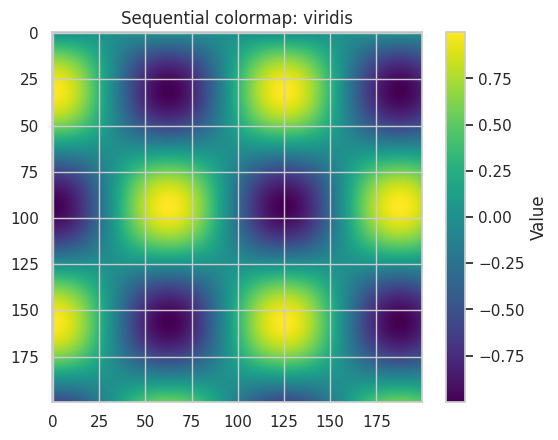

In [5]:

plt.figure()
plt.imshow(Z, cmap="viridis")
plt.title("Sequential colormap: viridis")
plt.colorbar(label="Value")
plt.show()

### Sequential — problematic (jet / rainbow)

- Notice how artificial boundaries appear due to uneven lightness.


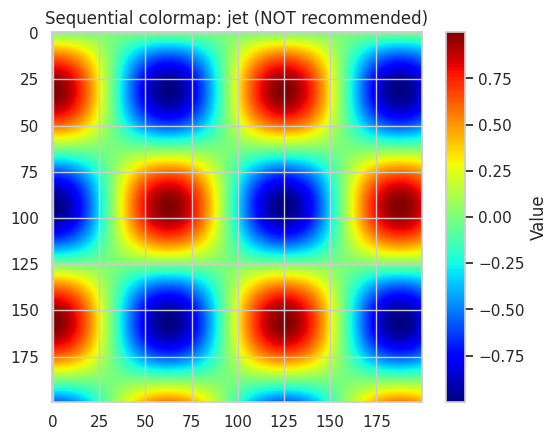

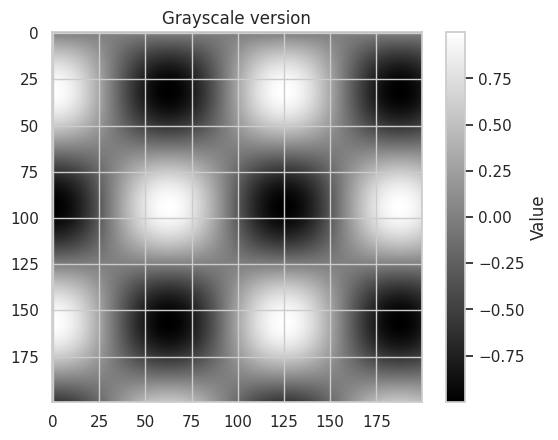

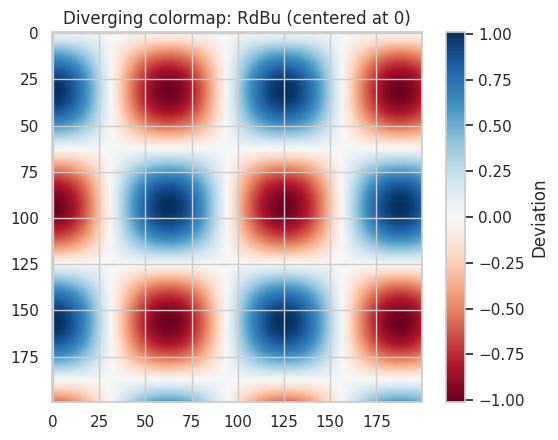

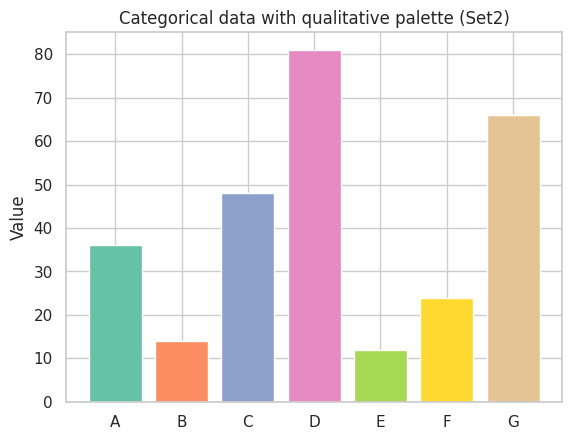

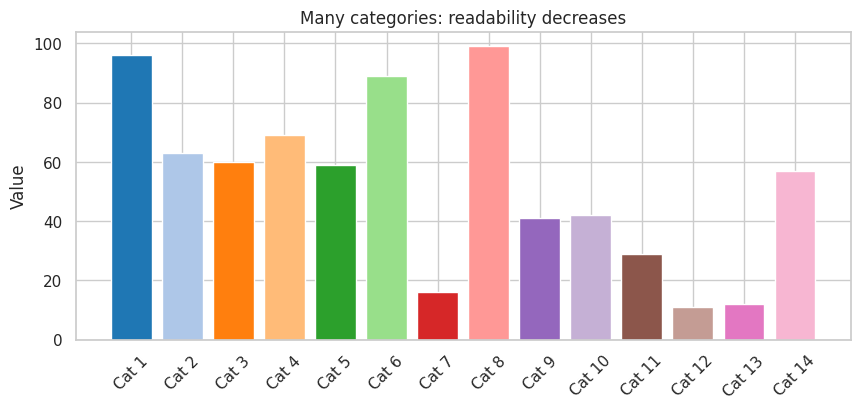

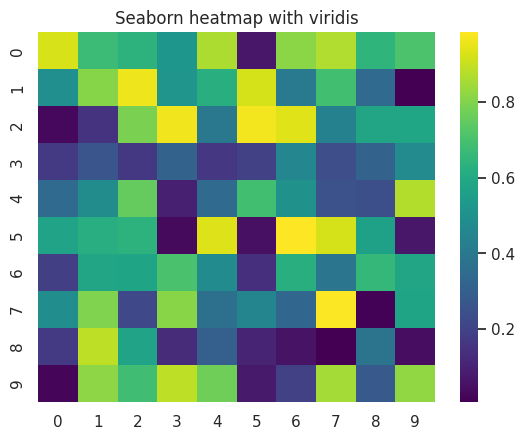

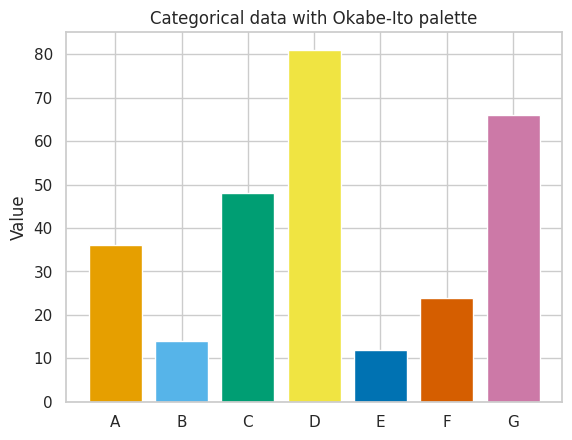

In [6]:

# %%
plt.figure()
plt.imshow(Z, cmap="jet")
plt.title("Sequential colormap: jet (NOT recommended)")
plt.colorbar(label="Value")
plt.show()

# %% [markdown]
# ## 2. Grayscale check (quick perceptual test)
#
# A good sequential colormap should still make sense in grayscale.

# %%
plt.figure()
plt.imshow(Z, cmap="gray")
plt.title("Grayscale version")
plt.colorbar(label="Value")
plt.show()

# %% [markdown]
# ## 3. Diverging data
#
# Use diverging palettes when data has a meaningful midpoint (e.g., zero).

# %%
Z_centered = Z - Z.mean()
max_abs = np.max(np.abs(Z_centered))

# %%
plt.figure()
plt.imshow(
    Z_centered,
    cmap="RdBu",
    vmin=-max_abs,
    vmax=max_abs
)
plt.title("Diverging colormap: RdBu (centered at 0)")
plt.colorbar(label="Deviation")
plt.show()

# %% [markdown]
# ## 4. Qualitative (categorical) color palettes
#
# Use these when categories have **no intrinsic order**.

# %%
categories = ["A", "B", "C", "D", "E", "F", "G"]
values = np.random.randint(10, 100, size=len(categories))

# %%
palette = sns.color_palette("Set2")

plt.figure()
plt.bar(categories, values, color=palette)
plt.title("Categorical data with qualitative palette (Set2)")
plt.ylabel("Value")
plt.show()

# %% [markdown]
# ## 5. Too many categories problem
#
# Humans struggle to distinguish many hues reliably.

# %%
many_categories = [f"Cat {i}" for i in range(1, 15)]
many_values = np.random.randint(10, 100, size=len(many_categories))

# %%
plt.figure(figsize=(10, 4))
plt.bar(many_categories, many_values, color=sns.color_palette("tab20"))
plt.title("Many categories: readability decreases")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.show()

# %% [markdown]
# ## 6. Seaborn heatmap example
#
# Seaborn integrates well with perceptually uniform palettes.

# %%
data = np.random.rand(10, 10)

sns.heatmap(data, cmap="viridis")
plt.title("Seaborn heatmap with viridis")
plt.show()

# %% [markdown]
# ## 7. Colorblind‑friendly palettes
#
# The Okabe‑Ito palette is widely recommended for accessibility.

# %%
okabe_ito = [
    "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00",
    "#CC79A7"
]

plt.figure()
plt.bar(categories, values, color=okabe_ito[:len(categories)])
plt.title("Categorical data with Okabe‑Ito palette")
plt.ylabel("Value")
plt.show()

# %% [markdown]
# ## 8. Key takeaways (review)
#
# - Use **sequential palettes** (viridis, cividis) for ordered data
# - Use **diverging palettes** when there is a meaningful midpoint
# - Use **qualitative palettes** for categories (limit number of hues)
# - Avoid rainbow/jet for quantitative data
# - Always check accessibility (colorblindness & grayscale)
#
# **Exercise:**
# Replace the colormaps above with your own choices and justify them
# in terms of perceptual uniformity and accessibility.